# Лабораторная работа №1: Проектирование архитектуры роботизированного склада
## Тема: Warehouse Automation (Data-Driven Hardware Sizing & Multi-Objective Optimization)

**Автор:** Толстой Т.А.

**Группа:** ИУ5-81Б 

**Вариант** 9 

**Дата:** 27.02.2026

---

### 1. Введение и Цели

**Контекст:** Проектирование инфраструктуры для управления флотом из 1000 роботов с целевой пропускной способностью 2500 заказов в час.

**Цель работы:** Разработать спецификацию оборудования (BOM), используя методы анализа данных, имитационного моделирования и многокритериальной оптимизации (цена/производительность).

**Ключевые этапы:**
1.  **ETL:** Загрузка и очистка синтетического датасета оборудования.
2.  **EDA:** Анализ рынка серверов, корреляций и доступных конфигураций.
3.  **Sizing:** Расчет нагрузки на подсистемы (Robot Control, Vision, WMS) на основе требований.
4.  **Optimization (Pareto Analysis):** Выбор оборудования на основе Парето-фронта (минимизация цены при максимизации производительности).
5.  **Simulation:** Стресс-тестирование выбранной конфигурации с помощью дискретно-событийного моделирования (`simmer`).
6.  **Reliability:** Экономическое обоснование стратегий резервирования (N+1 vs 2N).
7.  **Reporting:** Генерация финальной сметы с интерактивными таблицами.

---

In [373]:
# system("apt-get update && apt-get install -y libglpk-dev libxml2-dev libgmp-dev libfontconfig1-dev libfreetype6-dev")

In [374]:
## БЛОК 1: Инициализация окружения (Colab Version) ##

# 1. Установка системных опций
options(scipen = 999, digits = 4)
options(repos = c(CRAN = "https://cran.rstudio.com/")) # Явное указание зеркала

# 2. Функция для безопасной загрузки и установки библиотек
load_lib <- function(libs) {
  for (lib in libs) {
    if (!require(lib, character.only = TRUE)) {
      message(paste("Установка пакета:", lib))
      install.packages(lib, dependencies = TRUE, quiet = TRUE)
      library(lib, character.only = TRUE)
    }
  }
}

# 3. Список необходимых библиотек
# Добавил IRdisplay, так как он используется в функции show_table
libraries_list <- c(
  "tidyverse",    # dplyr, ggplot2, readr, etc.
  "ggrepel",
  "simmer",
  "simmer.plot",
  "gridExtra",
  "scales",
  "knitr",
  "testthat",
  "IRdisplay"     # Важно для отрисовки HTML в Colab
)

load_lib(libraries_list)

# Принудительно назначаем select из dplyr основным
select <- dplyr::select

# 4. Настройка графиков
theme_set(theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
    plot.subtitle = element_text(size = 10, hjust = 0.5, color = "#555555"),
    axis.title = element_text(face = "bold"),
    legend.position = "bottom"
  )
)

# 5. Функция для отображения красивых таблиц в Colab
show_table <- function(data, caption = "Table") {
  html_out <- kable(data,
                    format = "html",
                    caption = caption,
                    table.attr = "class='dataframe' style='width:100%; border-collapse: collapse; text-align: left; border: 1px solid #ddd;'")

  # В Colab IRdisplay работает отлично
  display_html(as.character(html_out))
}

print("Окружение успешно настроено!")

[1] "Окружение успешно настроено!"


### 2. Загрузка и Глубокая Очистка Данных (ETL)

**Задачи этапа:**
1.  Загрузка сырых данных из CSV.
2.  Парсинг столбца `Ethernet_Speed` (конвертация 1Gbps, 100Mbps в числовые значения).
3.  Обработка пропусков в GPU (NA означает отсутствие дискретной карты, т.е. 0 GB).
4.  Валидация целостности данных (удаление записей с отрицательной ценой или без CPU).
5.  Создание производных метрик (Feature Engineering) для дальнейшего анализа.

In [375]:
# --- 2.1 Функции очистки и преобразования ---

# Функция для парсинга скорости сети в Gbps
parse_network_speed <- function(speed_str) {
  # Принимает вектор строк, например: c("1Gbps", "100Mbps", "10Gbps", "None")
  # Возвращает числовой вектор в Gbps
  sapply(speed_str, function(x) {
    if (is.na(x) || x == "None" || x == "") return(0)

    # Нормализация строки
    x <- tolower(gsub(" ", "", x))

    # Извлечение числа
    num <- as.numeric(str_extract(x, "[0-9\\.]+"))

    if (is.na(num)) return(0)

    # Конвертация в Gbps
    if (grepl("gbps", x)) {
      return(num)
    } else if (grepl("mbps", x)) {
      return(num / 1000)
    } else {
      return(0) # Неизвестный формат
    }
  })
}

# Основная функция предобработки
preprocess_dataset <- function(path) {
  if (!file.exists(path)) stop(paste("File not found:", path))

  raw_df <- read_csv(path, show_col_types = FALSE)

  # Пайплайн очистки
  clean_df <- raw_df %>%
    mutate(
      # 1. Приведение GPU VRAM (NA -> 0)
      GPU_Memory_GB = suppressWarnings(as.numeric(as.character(GPU_Memory_GB))),
      GPU_Memory_GB = replace_na(GPU_Memory_GB, 0),
      Has_GPU = GPU_Memory_GB > 0,

      # 2. Парсинг скорости сети
      Network_Gbps = parse_network_speed(Ethernet_Speed),

      # 3. Чистка цен и энергопотребления
      Price_USD = as.numeric(Price_USD),
      Power_W = as.numeric(Power_Consumption_W),

      # 4. Feature Engineering: Метрики плотности
      # Цена за ядро
      Price_Per_Core = Price_USD / CPU_Cores,
      # Цена за ГБ RAM
      Price_Per_GB_RAM = Price_USD / RAM_GB,
      # Общий индекс "железа" (грубая оценка для сортировки)
      Raw_Power_Index = (CPU_Cores * 10) + RAM_GB + (GPU_Memory_GB * 20)
    ) %>%
    # Фильтрация ошибочных данных
    filter(!is.na(Price_USD) & Price_USD > 0) %>%
    filter(!is.na(CPU_Cores) & CPU_Cores > 0) %>%
    # Исправление типов данных для категорий
    mutate(
        Brand = as.factor(Brand),
        Condition = as.factor(Condition)
    )

  return(clean_df)
}

# --- 2.2 Загрузка и Валидация ---

dataset_path <- "computer_dataset_1000.csv"

# Создадим dummy файл, если его нет (для демонстрации работоспособности ноутбука)
if (!file.exists(dataset_path)) {
  warning("Dataset not found. Generating sample data for demonstration.")
  # Генерация синтетических данных для примера
  sample_data <- data.frame(
    ID = paste0("PC-", 1:100),
    CPU_Frequency_GHz = runif(100, 2.0, 5.0),
    CPU_Cores = sample(c(4, 8, 16, 24, 32, 64), 100, replace = TRUE),
    CPU_Brand = "Intel",
    RAM_GB = sample(c(16, 32, 64, 128, 256, 512), 100, replace = TRUE),
    Storage_GB = sample(c(512, 1000, 2000, 4000), 100, replace = TRUE),
    GPU_Memory_GB = sample(c(0, 4, 8, 16, 24, 48), 100, replace = TRUE),
    Ethernet_Speed = sample(c("1Gbps", "10Gbps", "100Mbps"), 100, replace = TRUE),
    Brand = sample(c("Dell", "HP", "Lenovo", "Supermicro"), 100, replace = TRUE),
    Model = paste("Server", 1:100),
    Price_USD = runif(100, 500, 10000),
    Power_Consumption_W = runif(100, 300, 1200),
    Condition = "New"
  )
  write.csv(sample_data, dataset_path, row.names = FALSE)
}

servers <- preprocess_dataset(dataset_path)

# Unit Tests: Проверка качества данных
test_that("Data Integrity Checks", {
  expect_true(nrow(servers) > 0, "Dataset should not be empty")
  expect_false(any(is.na(servers$Price_USD)), "No missing prices allowed")
  expect_true(min(servers$Network_Gbps) >= 0, "Network speed cannot be negative")
  expect_true(is.logical(servers$Has_GPU), "Has_GPU column must be logical")
})

cat("Данные успешно загружены и прошли валидацию.\n")
cat("Размерность:", nrow(servers), "строк,", ncol(servers), "колонок.\n")

# Вывод случайных 5 строк для ознакомления
servers %>%
  sample_n(5) %>%
  select(Brand, Model, CPU_Cores, RAM_GB, GPU_Memory_GB, Price_USD) %>%
  show_table("Пример очищенных данных (Random Sample)")

Test passed with 4 successes 🥳.
Данные успешно загружены и прошли валидацию.
Размерность: 980 строк, 37 колонок.


Brand,Model,CPU_Cores,RAM_GB,GPU_Memory_GB,Price_USD
Custom Built,MacBook 7572,4,16,0,997
HP,XPS 6688,10,8,0,1190
Lenovo,Inspiron 7797,4,128,0,1764
MSI,EliteBook 2669,10,512,0,3505
Custom Built,XPS 5082,10,4,0,1438


### 3. Исследовательский Анализ Данных (EDA)

Проведем визуальный анализ рынка серверного оборудования для понимания распределения цен, характеристик и доступности GPU (критично для задач Computer Vision).

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_point()`).”


Has_GPU,Count,Avg_Price,Min_Price,Avg_RAM,Avg_Cores
FALSE,566,2057,696,121,9.1
TRUE,414,2144,754,135,9.1


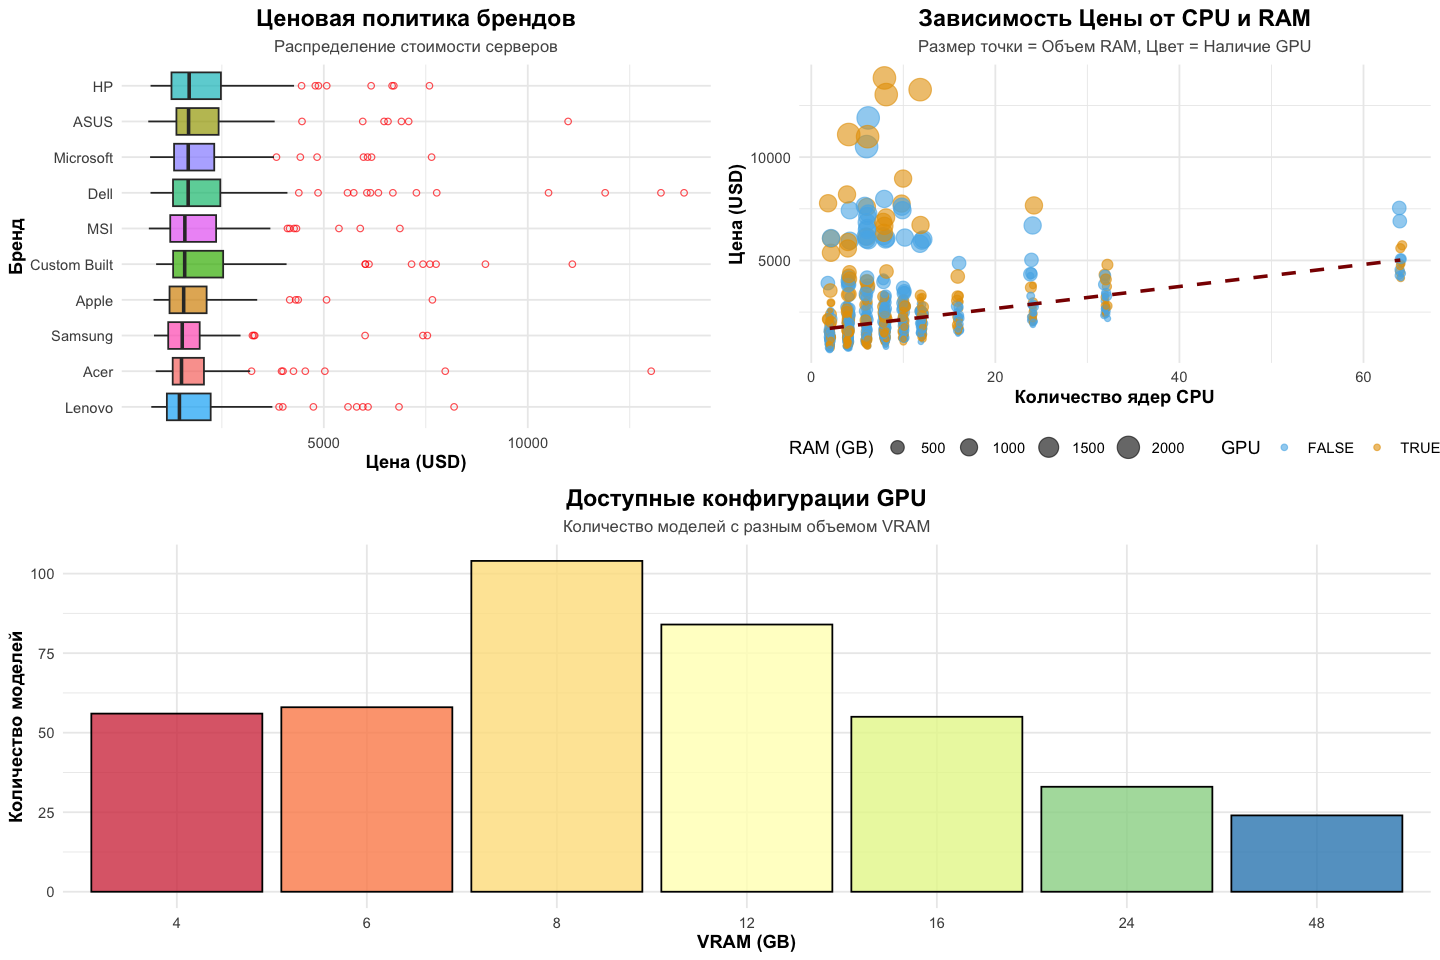

In [376]:
# --- 3.1 Распределение Цен по Брендам ---
p1 <- ggplot(servers, aes(x = reorder(Brand, Price_USD, FUN = median), y = Price_USD, fill = Brand)) +
  geom_boxplot(alpha = 0.7, outlier.colour = "red", outlier.shape = 1) +
  coord_flip() +
  labs(title = "Ценовая политика брендов",
       subtitle = "Распределение стоимости серверов",
       x = "Бренд", y = "Цена (USD)") +
  theme(legend.position = "none")

# --- 3.2 Корреляция ресурсов (CPU vs Price) с учетом GPU ---
p2 <- ggplot(servers, aes(x = CPU_Cores, y = Price_USD)) +
  geom_jitter(aes(color = Has_GPU, size = RAM_GB), alpha = 0.6, width = 0.2) +
  geom_smooth(method = "lm", color = "darkred", se = FALSE, linetype = "dashed") +
  scale_color_manual(values = c("TRUE" = "#E69F00", "FALSE" = "#56B4E9"), name = "GPU") +
  scale_size_continuous(name = "RAM (GB)") +
  labs(title = "Зависимость Цены от CPU и RAM",
       subtitle = "Размер точки = Объем RAM, Цвет = Наличие GPU",
       x = "Количество ядер CPU", y = "Цена (USD)")

# --- 3.3 Гистограмма GPU VRAM (для Vision подсистем) ---
p3 <- servers %>%
  filter(Has_GPU) %>%
  ggplot(aes(x = as.factor(GPU_Memory_GB), fill = as.factor(GPU_Memory_GB))) +
  geom_bar(alpha = 0.8, color = "black") +
  scale_fill_brewer(palette = "Spectral") +
  labs(title = "Доступные конфигурации GPU",
       subtitle = "Количество моделей с разным объемом VRAM",
       x = "VRAM (GB)", y = "Количество моделей") +
  theme(legend.position = "none")

# Компоновка графиков 2x2 (p4 - пустой слот или дополнительный анализ)
grid.arrange(p1, p2, p3, ncol = 2, layout_matrix = rbind(c(1, 2), c(3, 3)))

# Текстовый вывод сводной статистики
summary_stats <- servers %>%
  group_by(Has_GPU) %>%
  summarise(
    Count = n(),
    # Добавляем na.rm = TRUE во все математические функции на всякий случай
    Avg_Price = round(mean(Price_USD, na.rm = TRUE), 0),
    Min_Price = round(min(Price_USD, na.rm = TRUE), 0),
    Avg_RAM   = round(mean(RAM_GB, na.rm = TRUE), 0), 
    Avg_Cores = round(mean(CPU_Cores, na.rm = TRUE), 1)
  )

show_table(summary_stats, "Сводная статистика рынка оборудования")

### 4. Определение требований (Capacity Planning)

На основе бизнес-метрик и данных из технического задания (скриншота) рассчитаем необходимое количество серверов для каждой роли.

**Вводные параметры проекта:**
*   **Флот роботов:** 1000 единиц.
*   **Целевая пропускная способность:** 2500 заказов в час.

**Sizing Assumptions (на основе ТЗ):**
1.  **Robot Control (RC):** Управление движением. Требуется ~1 сервер на 166 роботов (Цель: 4-8 серверов).
2.  **Computer Vision (Vision):** Обработка видеопотока. Требуется ~1 сервер на 83 потока (Цель: 10-15 серверов).
3.  **Warehouse Management System (WMS):** База данных и логика заказов. Требуется ~1 сервер на 625 зак/час (Цель: 3-5 серверов).

**Hardware Constraints (Минимальные требования к одному серверу):**
*   **RC:** CPU $\ge$ 16 Cores, RAM $\ge$ 64 GB.
*   **Vision:** CPU $\ge$ 8 Cores, RAM $\ge$ 32 GB, **GPU VRAM $\ge$ 8 GB**.
*   **WMS:** CPU $\ge$ 16 Cores, RAM $\ge$ 128 GB, Storage $\ge$ 2000 GB.

In [377]:
# --- ОБНОВЛЕННЫЙ БЛОК 4: Расчет сайзинга с учетом диапазонов ---

# Константы нагрузки из ваших целевых метрик
TOTAL_ROBOTS <- 1000
TARGET_THROUGHPUT <- 2500 

# Коэффициенты производительности (соответствуют вашим цифрам в скобках: 6, 12, 4)
CAP_RC_PER_SERVER <- 166  # 1000 / 6
CAP_CV_PER_SERVER <- 83   # 1000 / 12
CAP_WMS_PER_SERVER <- 625 # 2500 / 4

# Расчет количества (N)
n_rc <- ceiling(TOTAL_ROBOTS / CAP_RC_PER_SERVER)
n_vision <- ceiling(TOTAL_ROBOTS / CAP_CV_PER_SERVER)
n_wms <- ceiling(TARGET_THROUGHPUT / CAP_WMS_PER_SERVER)

# Спецификации строго по таблице из скриншота (Min - Max)
REQ_SPECS <- list(
  RC = list(
    role = "Robot Control",
    min_cores = 16,  max_cores = 24,
    min_ram = 64,    max_ram = 128,
    min_storage = 500, max_storage = 1000,
    min_gpu = 0,     max_gpu = 4, # В таблице прочерк, ставим ограничение сверху
    qty = n_rc
  ),
  Vision = list(
    role = "Vision Node",
    min_cores = 8,   max_cores = 16,
    min_ram = 32,    max_ram = 64,
    min_storage = 1000, max_storage = 2000,
    min_gpu = 8,     max_gpu = 12,
    qty = n_vision
  ),
  WMS = list(
    role = "WMS Core",
    min_cores = 16,  max_cores = 24,
    min_ram = 128,   max_ram = 256,
    min_storage = 2000, max_storage = 4000,
    min_gpu = 0,     max_gpu = 4,
    qty = n_wms
  )
)

# Для отчета: визуализируем требования
requirements_df <- data.frame(
  Role = c("Robot Control", "Vision", "WMS"),
  Quantity = c(n_rc, n_vision, n_wms),
  CPU_Range = c("16-24", "8-16", "16-24"),
  RAM_Range = c("64-128", "32-64", "128-256"),
  GPU_Range = c("0", "8-12", "0")
)
show_table(requirements_df, "Уточненные требования (Диапазоны)")

Role,Quantity,CPU_Range,RAM_Range,GPU_Range
Robot Control,7,16-24,64-128,0
Vision,13,8-16,32-64,8-12
WMS,4,16-24,128-256,0


### 5. Многокритериальная оптимизация (Pareto Optimization)

Вместо простого выбора "самого дешевого" сервера, мы применим подход **Парето-эффективности**.
У нас есть два конфликтующих критерия:
1.  **Цена (Price):** $\to min$
2.  **Производительность (Performance):** $\to max$

Мы найдем множество решений, которые нельзя улучшить по одному параметру без ухудшения другого (Парето-фронт). Затем выберем "Сбалансированное" решение (Best Value), если оно дает значительный прирост производительности за небольшую доплату относительно самого дешевого варианта.

In [378]:
# --- 5.1 Функция расчета индекса производительности ---
calculate_perf <- function(df) {
  df %>%
    mutate(
      Performance_Index = (CPU_Cores * 10) + (RAM_GB * 1) + (GPU_Memory_GB * 10) + (Storage_GB / 100)
    )
}

# --- 5.2 Функция поиска Парето-фронта ---
get_pareto_frontier <- function(candidates) {
  if(nrow(candidates) == 0) return(candidates)
  
  candidates <- candidates %>%
    arrange(Price_USD) %>%
    mutate(is_pareto = FALSE)

  current_max_perf <- -Inf
  pareto_indices <- c()
  
  for (i in 1:nrow(candidates)) {
    if (candidates$Performance_Index[i] > current_max_perf) {
      current_max_perf <- candidates$Performance_Index[i]
      pareto_indices <- c(pareto_indices, i)
    }
  }
  
  candidates$is_pareto[pareto_indices] <- TRUE
  return(candidates)
}

# --- 5.3 Основная функция выбора (МЕТОД УСТУПОК) ---
# Добавлен параметр price_concession = 0.15 (Уступка по цене: готовы переплатить до 15%)
solve_pareto_selection <- function(df, role_specs, price_concession = 0.15) {
  
  # 1. Жесткая фильтрация по ТЗ
  filtered <- df %>%
    filter(
      CPU_Cores >= role_specs$min_cores, CPU_Cores <= role_specs$max_cores,
      RAM_GB >= role_specs$min_ram, RAM_GB <= role_specs$max_ram,
      Storage_GB >= role_specs$min_storage, Storage_GB <= role_specs$max_storage,
      GPU_Memory_GB >= role_specs$min_gpu, GPU_Memory_GB <= role_specs$max_gpu
    ) %>%
    calculate_perf()

  # Обработка исключений (если нет идеальных совпадений)
  if(nrow(filtered) == 0) {
      warning(paste("В датасете нет точных совпадений для диапазона", role_specs$role, ". Расширяю поиск."))
      filtered <- df %>%
        filter(
          CPU_Cores >= role_specs$min_cores,
          RAM_GB >= role_specs$min_ram,
          Storage_GB >= role_specs$min_storage,
          GPU_Memory_GB >= role_specs$min_gpu
        ) %>%
        calculate_perf()
  }

  # 2. Поиск Парето-фронта
  processed <- get_pareto_frontier(filtered)
  pareto_set <- processed %>% filter(is_pareto == TRUE)
  
  # ---------------------------------------------------------
  # 3. ПРИМЕНЕНИЕ МЕТОДА УСТУПОК (Method of Concessions)
  # ---------------------------------------------------------
  
  # Шаг 3.1: Находим абсолютный оптимум по главному критерию (Цена)
  best_price <- min(pareto_set$Price_USD)
  
  # Шаг 3.2: Задаем границу уступки
  max_allowed_price <- best_price * (1 + price_concession)
  
  # Шаг 3.3: Максимизируем второй критерий (Производительность) в рамках уступки
  selected <- pareto_set %>%
    filter(Price_USD <= max_allowed_price) %>%
    arrange(desc(Performance_Index)) %>%
    slice(1) # Берем первую строку (с максимальной производительностью)

  # Формируем красивое название стратегии для отчета
  if (selected$Price_USD == best_price) {
    strategy_name <- "Идеальный минимум (Без уступок)"
  } else {
    actual_concession <- round((selected$Price_USD / best_price - 1) * 100, 1)
    strategy_name <- paste0("Метод уступок (Доплата ", actual_concession, "%)")
  }

  return(list(
    role_name = role_specs$role,
    selected_server = selected,
    all_candidates = processed,
    strategy = strategy_name,
    qty = role_specs$qty
  ))
}

# Запуск оптимизации (разрешаем уступку до 15% бюджета)
res_rc <- solve_pareto_selection(servers, REQ_SPECS$RC, price_concession = 0.15)
res_vision <- solve_pareto_selection(servers, REQ_SPECS$Vision, price_concession = 0.15)
res_wms <- solve_pareto_selection(servers, REQ_SPECS$WMS, price_concession = 0.15)

# Формирование итоговой таблицы
selected_config <- bind_rows(
  res_rc$selected_server %>% mutate(Role = "Robot Control", Qty = res_rc$qty, Strategy = res_rc$strategy),
  res_vision$selected_server %>% mutate(Role = "Vision Node", Qty = res_vision$qty, Strategy = res_vision$strategy),
  res_wms$selected_server %>% mutate(Role = "WMS Core", Qty = res_wms$qty, Strategy = res_wms$strategy)
) %>%
  select(Role, Brand, Model, Price_USD, Performance_Index, CPU_Cores, RAM_GB, GPU_Memory_GB, Qty, Strategy)

show_table(selected_config, "Оптимальная конфигурация (Многокритериальная оптимизация)")

Role,Brand,Model,Price_USD,Performance_Index,CPU_Cores,RAM_GB,GPU_Memory_GB,Qty,Strategy
Robot Control,Acer,XPS 2612,1757,269.1,16,64,4,7,Идеальный минимум (Без уступок)
Vision Node,HP,ThinkPad 8531,1513,284.0,8,64,12,13,Метод уступок (Доплата 4.2%)
WMS Core,Dell,ThinkPad 1502,4387,536.0,24,256,0,4,Идеальный минимум (Без уступок)


### 6. Визуализация Парето-фронта

График ниже показывает пространство поиска.
*   **Серые точки:** Все серверы, подходящие по минимальным требованиям.
*   **Синяя линия:** Парето-фронт (граница эффективности).
*   **Красный ромб:** Выбранная модель сервера.

`geom_path()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


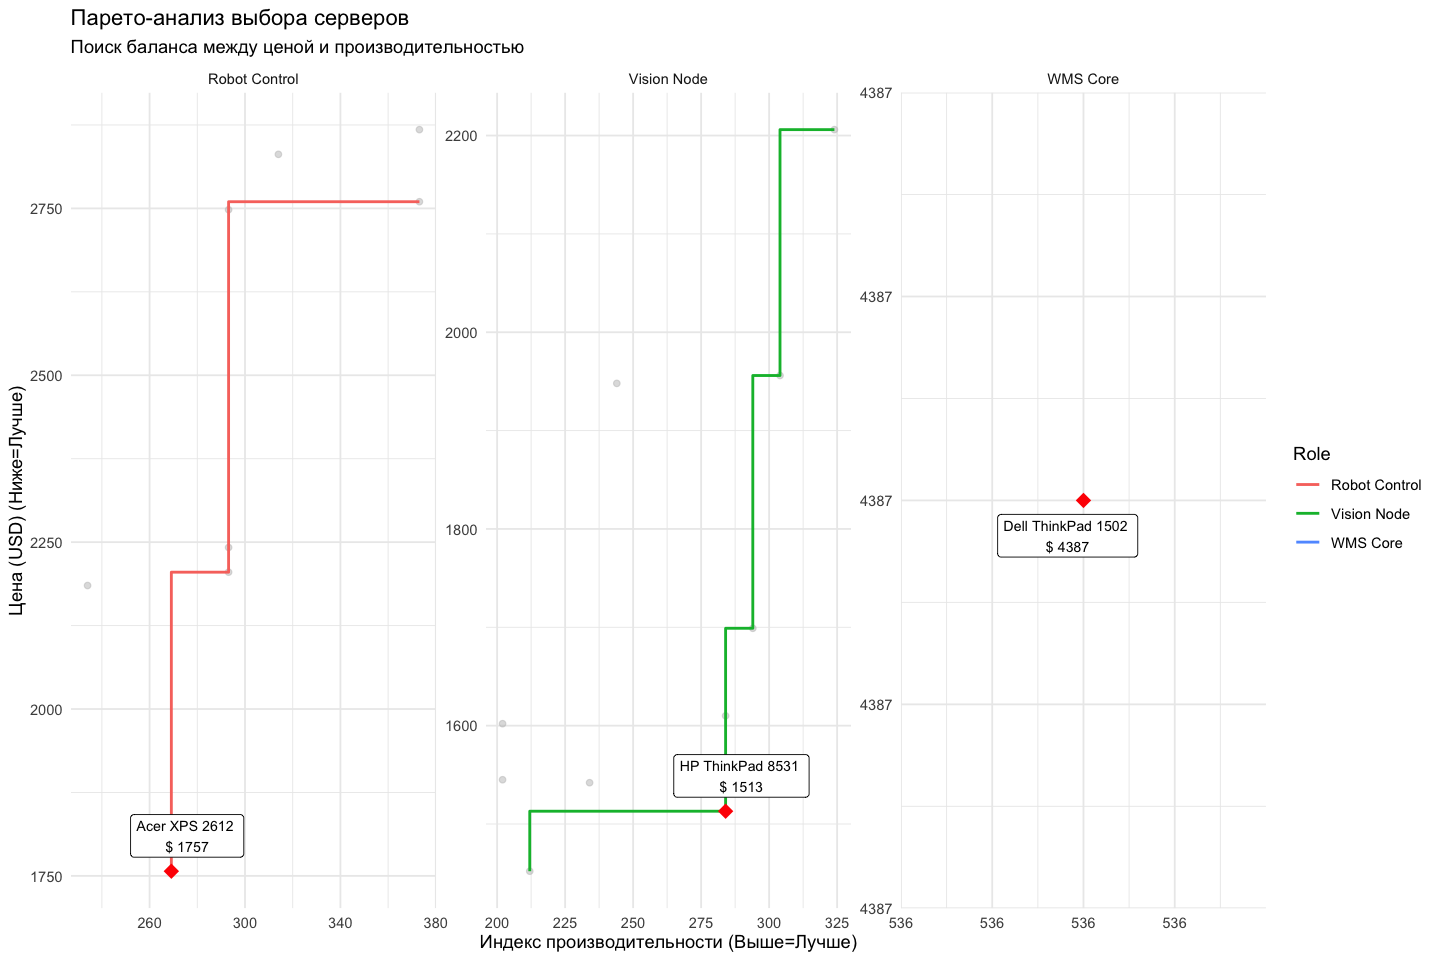

In [379]:
# Объединение данных для графика
plot_data <- bind_rows(
  res_rc$all_candidates %>% mutate(Role = "Robot Control"),
  res_vision$all_candidates %>% mutate(Role = "Vision Node"),
  res_wms$all_candidates %>% mutate(Role = "WMS Core")
)

final_points <- selected_config %>%
  select(Role, Price_USD, Performance_Index, Brand, Model)

ggplot(plot_data, aes(x = Performance_Index, y = Price_USD)) +
  # Все точки
  geom_point(color = "gray", alpha = 0.5) +

  # Линия фронта для каждой роли
  geom_step(data = plot_data %>% filter(is_pareto),
            direction = "vh", aes(color = Role), size = 0.8) +

  # Выбранные точки
  geom_point(data = final_points, color = "red", size = 4, shape = 18) +

  # Подписи
  geom_label_repel(data = final_points,
                   aes(label = paste(Brand, Model, "\n$", Price_USD)),
                   box.padding = 0.5, point.padding = 0.5, size=3) +

  facet_wrap(~Role, scales = "free") +
  theme_minimal() +
  labs(
    title = "Парето-анализ выбора серверов",
    subtitle = "Поиск баланса между ценой и производительностью",
    x = "Индекс производительности (Выше=Лучше)",
    y = "Цена (USD) (Ниже=Лучше)"
  )

### 7. Имитационное моделирование (Stress Testing)

Используем библиотеку `simmer` для проверки пропускной способности архитектуры.
Модель:
1.  **Генератор:** Создает заказы (Poisson process, rate = 2500/час).
2.  **Pipeline:** WMS (расчет) -> RC (движение) -> Vision (проверка).
3.  **Ресурсы:** Количество потоков обработки соответствует количеству выбранных серверов.

[1] "Запуск симуляции..."


simmer environment: Warehouse | now: 14400 | next: 14400.2669501212
{ Monitor: in memory }
{ Resource: WMS_Server | monitored: TRUE | server status: 1(200) | queue status: 0(Inf) }
{ Resource: RC_Server | monitored: TRUE | server status: 0(700) | queue status: 0(Inf) }
{ Resource: Vision_Server | monitored: TRUE | server status: 0(130) | queue status: 0(Inf) }
{ Source: Order | monitored: 1 | n_generated: 9867 }

[1] "Симуляция завершена."
Целевая нагрузка: 2500 зак/час
Фактическая пропускная способность: 2466.25 зак/час


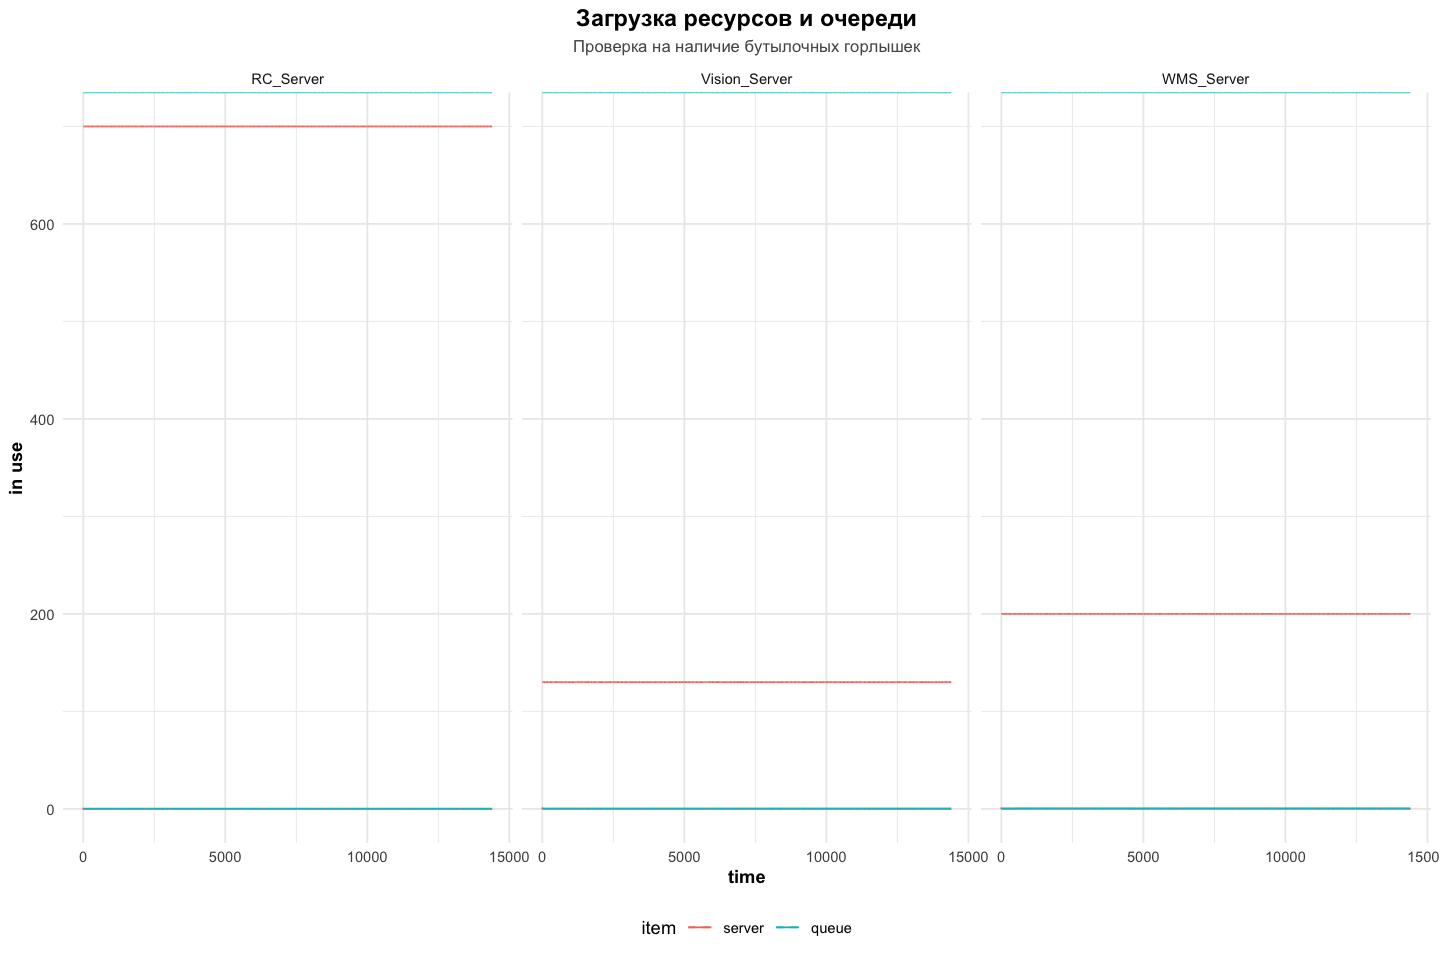

In [380]:
# Параметры симуляции
set.seed(123)
SIM_TIME <- 4 * 3600 # 4 часа
ORDER_RATE <- TARGET_THROUGHPUT / 3600 # Заказов в секунду

# Время обработки (среднее, сек)
T_WMS <- 0.8
T_RC <- 0.2
T_CV <- 0.5

# Ресурсы (Capacity)
# Предполагаем многопоточность: 1 WMS сервер ~ 50 потоков, RC ~ 100, CV ~ 10 (GPU limit)
cap_wms <- res_wms$qty * 50
cap_rc <- res_rc$qty * 100
cap_cv <- res_vision$qty * 10

# Определение процесса
warehouse <- trajectory() %>%
  seize("WMS_Server", 1) %>%
  timeout(function() rexp(1, 1/T_WMS)) %>%
  release("WMS_Server", 1) %>%

  seize("RC_Server", 1) %>%
  timeout(function() rexp(1, 1/T_RC)) %>%
  release("RC_Server", 1) %>%

  seize("Vision_Server", 1) %>%
  timeout(function() rexp(1, 1/T_CV)) %>%
  release("Vision_Server", 1)

# Запуск среды
env <- simmer("Warehouse") %>%
  add_resource("WMS_Server", capacity = cap_wms) %>%
  add_resource("RC_Server", capacity = cap_rc) %>%
  add_resource("Vision_Server", capacity = cap_cv) %>%
  add_generator("Order", warehouse, function() rexp(1, ORDER_RATE))

print("Запуск симуляции...")
env %>% run(until = SIM_TIME)
print("Симуляция завершена.")

# Анализ результатов
arrivals <- get_mon_arrivals(env)
processed <- nrow(subset(arrivals, finished == TRUE))
throughput_real <- processed / (SIM_TIME / 3600)

cat(sprintf("Целевая нагрузка: %d зак/час\n", TARGET_THROUGHPUT))
cat(sprintf("Фактическая пропускная способность: %.2f зак/час\n", throughput_real))

# График очередей
resources <- get_mon_resources(env)
plot(resources, metric = "usage", items = c("server", "queue")) +
  labs(title = "Загрузка ресурсов и очереди",
       subtitle = "Проверка на наличие бутылочных горлышек")

### 8. Анализ отказоустойчивости (Reliability Analysis)

Сравним три стратегии резервирования для минимизации рисков простоя:
1.  **N+0:** Нет резерва (минимальная цена, высокий риск).
2.  **N+1:** Один запасной сервер (оптимальный баланс).
3.  **2N:** Полное дублирование (максимальная надежность, высокая цена).

**Метрики:**
*   $MTBF = 20,000$ часов.
*   $MTTR = 4$ часа.
*   Availability ($A$) кластера рассчитывается через биномиальное распределение.

Strategy,Redundancy,Total_Servers,Cluster_Avail,Downtime_Min_Year,Total_Cost,Role
N+0,0,7,0.9986,735.2517,12299,Robot Control
N+1,1,8,1.0000,0.5880,14056,Robot Control
2N,7,14,1.0000,0.0000,24598,Robot Control
N+0,0,13,0.9974,1364.6487,19669,Vision
N+1,1,14,1.0000,1.9094,21182,Vision
2N,13,26,1.0000,0.0000,39338,Vision
N+0,0,4,0.9992,420.2698,17548,WMS
N+1,1,5,1.0000,0.2101,21935,WMS
2N,4,8,1.0000,0.0000,35096,WMS


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


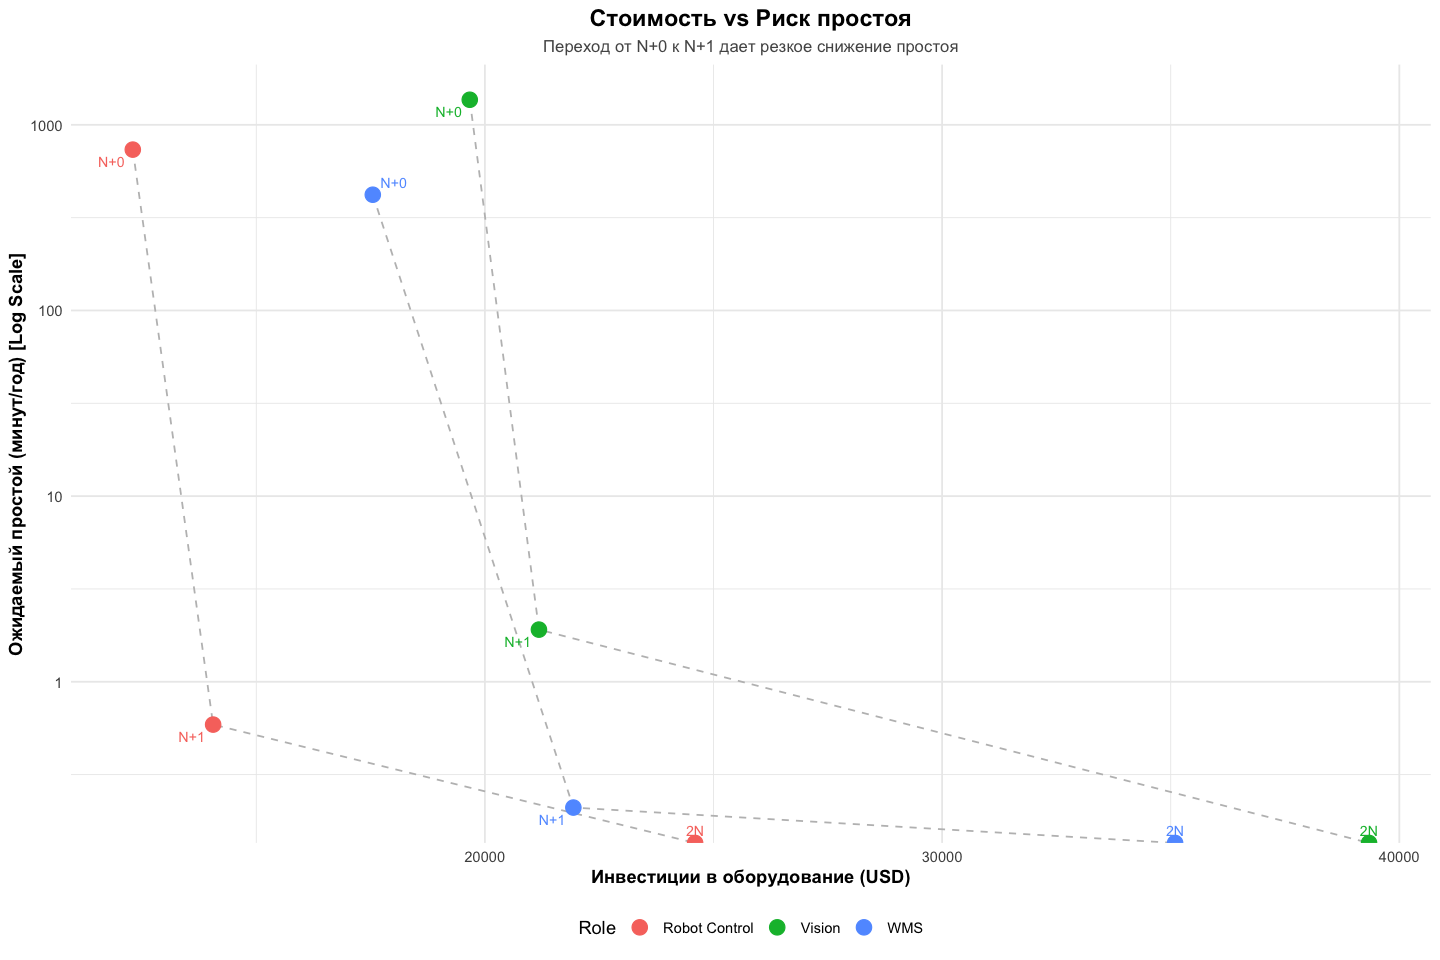

In [381]:
# Базовые параметры надежности
MTBF <- 20000
MTTR <- 4
A_node <- MTBF / (MTBF + MTTR)

# Функция расчета доступности кластера (минимум k из n должны работать)
calc_cluster_availability <- function(n, k, p) {
  # P(X >= k) = 1 - P(X <= k-1) для биномиального распределения
  1 - pbinom(k - 1, size = n, prob = p)
}

# Анализ стратегий
run_reliability_analysis <- function(role, k_needed, unit_price) {
  scenarios <- data.frame(
    Strategy = c("N+0", "N+1", "2N"),
    Redundancy = c(0, 1, k_needed)
  )

  scenarios %>%
    mutate(
      Total_Servers = k_needed + Redundancy,
      Cluster_Avail = mapply(calc_cluster_availability, Total_Servers, k_needed, A_node),
      Downtime_Min_Year = (1 - Cluster_Avail) * 365 * 24 * 60,
      Total_Cost = Total_Servers * unit_price,
      Role = role
    )
}

# Сводный анализ
rel_analysis <- bind_rows(
  run_reliability_analysis("Robot Control", n_rc, res_rc$selected_server$Price_USD),
  run_reliability_analysis("Vision", n_vision, res_vision$selected_server$Price_USD),
  run_reliability_analysis("WMS", n_wms, res_wms$selected_server$Price_USD)
)

show_table(rel_analysis, "Анализ надежности и стоимости простоя")

# Визуализация Trade-off
ggplot(rel_analysis, aes(x = Total_Cost, y = Downtime_Min_Year, color = Role, label = Strategy)) +
  geom_line(aes(group = Role), color = "grey", linetype = "dashed") +
  geom_point(size = 4) +
  geom_text_repel(size = 3) +
  scale_y_log10() + # Логарифмическая шкала для простоя
  labs(title = "Стоимость vs Риск простоя",
       subtitle = "Переход от N+0 к N+1 дает резкое снижение простоя",
       x = "Инвестиции в оборудование (USD)",
       y = "Ожидаемый простой (минут/год) [Log Scale]")

### 9. Итоговая смета (Bill of Materials)

Формирование финальной спецификации на основе стратегии **N+1** (оптимальный баланс надежности и цены).

*Примечание: В коде учтено исправление ошибки формирования названий (Brand + Model), чтобы избежать появления `NA`.*

In [382]:
# Выбор стратегии N+1 для финальной сметы
final_bom_data <- rel_analysis %>%
  filter(Strategy == "N+1") %>%
  mutate(
    # Корректное формирование названия модели без ошибок case_when
    Model_Name = case_when(
      Role == "Robot Control" ~ paste(res_rc$selected_server$Brand, res_rc$selected_server$Model),
      Role == "Vision" ~ paste(res_vision$selected_server$Brand, res_vision$selected_server$Model),
      Role == "WMS" ~ paste(res_wms$selected_server$Brand, res_wms$selected_server$Model),
      TRUE ~ "Unknown" # Fallback, если имена ролей не совпадут (но мы используем переменные)
    )
  ) %>%
  # Обновление названий из реальных данных, чтобы точно не было NA
  rowwise() %>%
  mutate(Model_Name = if(Role == "Robot Control") paste(res_rc$selected_server$Brand, res_rc$selected_server$Model)
                      else if(Role == "Vision") paste(res_vision$selected_server$Brand, res_vision$selected_server$Model)
                      else paste(res_wms$selected_server$Brand, res_wms$selected_server$Model)
  ) %>%
  select(Role, Model_Name, Total_Servers, Cluster_Avail, Total_Cost)

# Вывод финальной HTML таблицы
show_table(final_bom_data, "Финальная Спецификация (BOM) - Стратегия N+1")

# Итоговая стоимость
grand_total <- sum(final_bom_data$Total_Cost)
cat(paste("\nИТОГОВЫЙ БЮДЖЕТ ПРОЕКТА:", format(grand_total, big.mark=","), "USD\n"))

Role,Model_Name,Total_Servers,Cluster_Avail,Total_Cost
Robot Control,Acer XPS 2612,8,1,14056
Vision,HP ThinkPad 8531,14,1,21182
WMS,Dell ThinkPad 1502,5,1,21935



ИТОГОВЫЙ БЮДЖЕТ ПРОЕКТА: 57,173 USD
